<div style="display: flex; background-color: #7b002c;">
<div style="margin: auto; padding: 40px; color: white; font-size: 36px;">
<strong>
🍷 Analyse du stock et des ventes du site BottleNeck 🍷
</strong>
</div>
</div>

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white; ">
Importation des librairies et chargement des fichiers
</h1>
</div>

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Importation des librairies
</h2>
</div>

In [1]:
import numpy as np
import pandas as pd # openpyxl required to read/write Excel files
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # statsmodels required for trendline

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Chargement des fichiers Excel
</h2>
</div>

In [2]:
df_erp = pd.read_excel("data/erp.xlsx")

/home/user/Workspace/P6/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
df_liaison = pd.read_excel("data/liaison.xlsx")

/home/user/Workspace/P6/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [4]:
df_web = pd.read_excel("data/web.xlsx")

/home/user/Workspace/P6/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Les `UserWarning`s indiquent que `openpyxl` détecte des fonctionnalités spécifiques à Excel qui sont ignorées lors de la lecture des fichiers.

Cela n'est pas bloquant pour le bon chargement des données.

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Autres paramètres généraux
</h2>
</div>

In [5]:
# Couleur utilisée pour les entêtes
print(f"Couleur Bordeaux = {sns.colors.xkcd_rgb["bordeaux"]}")

Couleur Bordeaux = #7b002c


In [6]:
# @see https://fr.wikipedia.org/wiki/Coefficient_de_Gini#Calcul_pratique
def indice_gini(values):
    a = np.sort(values)
    n = len(a)
    return (a.dot(range(1, n+1)) / a.sum() * 2 - n - 1) / n

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white; ">
Analyse exploratoire des fichiers
</h1>
</div>

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse exploratoire du fichier : erp.xlsx
</h2>
</div>

In [7]:
print(f"Le tableau comporte {df_erp.shape[0]} observation(s) ou article(s).")
print(f"Le tableau comporte {df_erp.shape[1]} colonne(s).")

Le tableau comporte 825 observation(s) ou article(s).
Le tableau comporte 6 colonne(s).


In [8]:
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
df_erp.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


Il y a **825** produits référencés dans l'ERP. De plus, il n'y a *aucune valeur manquante*.

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de chaque colonne
</h3>
</div>

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : product_id
</h4>
</div>

In [10]:
any_duplicated = df_erp.duplicated(subset="product_id", keep=False).any()
print(f"Doublons dans la colonne product_id ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne product_id ? Non


La colonne `product_id` sert d'identifiant dans l'ERP. Il n'y a *aucun doublon*.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : onsale_web
</h4>
</div>

In [11]:
pd.unique(df_erp["onsale_web"])

array([1, 0])

In [12]:
df_erp["onsale_web"].sum()

np.int64(716)

La colonne `onsale_web` semble indiquer si un produit est actuellement en vente sur le site web (1 = true) ou non (0 = false). Il devrait y avoir **716** produits en vente.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : price
</h4>
</div>

In [13]:
print(f"Nombres d'articles avec un prix non renseigné = {df_erp["price"].isna().sum()}")
print(f"Nombres d'articles avec un prix négatif = {(df_erp["price"] < 0).sum()}")
print(f"Nombres d'articles avec un prix nul = {(df_erp["price"] == 0).sum()}")

Nombres d'articles avec un prix non renseigné = 0
Nombres d'articles avec un prix négatif = 3
Nombres d'articles avec un prix nul = 0


In [14]:
print(f"Prix max = {df_erp["price"].max()}")
print(f"Prix min = {df_erp["price"].min()}")

Prix max = 225.0
Prix min = -20.0


In [15]:
df_erp[ (df_erp["price"] < 0) ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


La colonne `price` contient des erreurs : **3** produits ont des prix négatifs.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : stock_quantity
</h4>
</div>

In [16]:
print(f"Nombres d'articles avec une quantité de stock non renseignée = {df_erp["stock_quantity"].isna().sum()}")
print(f"Nombres d'articles avec une quantité de stock négative = {(df_erp["stock_quantity"] < 0).sum()}")
print(f"Nombres d'articles avec une quantité de stock nulle = {(df_erp["stock_quantity"] == 0).sum()}")

Nombres d'articles avec une quantité de stock non renseignée = 0
Nombres d'articles avec une quantité de stock négative = 2
Nombres d'articles avec une quantité de stock nulle = 90


In [17]:
print(f"Quantité de stock max = {df_erp["stock_quantity"].max()}")
print(f"Quantité de stock min = {df_erp["stock_quantity"].min()}")

Quantité de stock max = 145
Quantité de stock min = -10


In [18]:
df_erp[ (df_erp["stock_quantity"] < 0) ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


La colonne `stock_quantity` contient des erreurs : **2** produits ont un nombre d'unités en stock négatif.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : stock_status
</h4>
</div>

In [19]:
pd.unique(df_erp["stock_status"])

array(['instock', 'outofstock'], dtype=object)

In [20]:
(df_erp["stock_status"] == "instock").sum()

np.int64(733)

La colonne `stock_status` semble indiquer si un produit est présent en stock (instock) ou non (outofstock).

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : purchase_price
</h4>
</div>

In [21]:
print(f"Nombres d'articles avec un prix fournisseur non renseigné = {df_erp["purchase_price"].isna().sum()}")
print(f"Nombres d'articles avec un prix fournisseur négatif = {(df_erp["purchase_price"] < 0).sum()}")
print(f"Nombres d'articles avec un prix fournisseur nul = {(df_erp["purchase_price"] == 0).sum()}")

Nombres d'articles avec un prix fournisseur non renseigné = 0
Nombres d'articles avec un prix fournisseur négatif = 0
Nombres d'articles avec un prix fournisseur nul = 0


In [22]:
print(f"Prix fournisseur max = {df_erp["purchase_price"].max()}")
print(f"Prix fournisseur min = {df_erp["purchase_price"].min()}")

Prix fournisseur max = 137.81
Prix fournisseur min = 2.74


La colonne `purchase_price` semble ne contenir *aucune erreur* (tous les prix fournisseur sont positifs).

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la cohérence entre colonnes
</h3>
</div>

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Incohérences entre price et purchase_price
</h4>
</div>

In [23]:
df_erp[ ~( (0 < df_erp["purchase_price"]) & (df_erp["purchase_price"] < df_erp["price"]) ) ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.00,0,outofstock,10.33
210,4355,1,12.65,97,instock,77.48
391,4864,0,8.30,0,outofstock,9.99
469,5017,0,-8.00,0,outofstock,4.34
724,6324,0,92.00,18,instock,99.00
739,6594,0,-9.10,19,instock,4.61
817,7196,0,31.00,55,instock,31.20


Il y a **7** produits pour lesquels le prix de vente est inférieur au prix fournisseur (marge négative).
Parmi eux, on retrouve les **3** produits avec un prix de vente négatif.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Incohérences entre stock_quantity et stock_status
</h4>
</div>

In [24]:
df_erp[ ((df_erp["stock_quantity"] == 0) != (df_erp["stock_status"] == "outofstock")) ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
4,4039,1,46.0,3,outofstock,23.77
398,4885,1,18.7,0,instock,9.66
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


En plus des **2** produits avec un nombre d'unités en stock négatif, on détecte **2** autres problèmes.

- 3 unités en stock pour le produit 4039, pourtant marqué en rupture de stock
- 0 unités en stock pour le produit 4885, pourtant marqué en stock

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse exploratoire du fichier : web.xlsx
</h2>
</div>

In [25]:
print(f"Le tableau comporte {df_web.shape[0]} observation(s) ou article(s).")
print(f"Le tableau comporte {df_web.shape[1]} colonne(s).")

Le tableau comporte 1513 observation(s) ou article(s).
Le tableau comporte 29 colonne(s).


In [26]:
df_web.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Structure générale : produits et images
</h3>
</div>

En ouvrant le fichier web.xlsx dans Excel, on remarque que chaque ligne semble correspondre à des documents dans une collection (e.g. base de données WordPress).

La colonne GUID désigne certainement un identifiant unique global du document dans la collection.

Hormis quelques lignes vides, on distingue deux types de documents indiqués dans la colonne `post_type` :

- "product" (description dans la colonne `post_excerpt`)

- "attachment" (image en pièce jointe)

Les blocs ci-dessous permettent de vérifier ces propriétés.

In [27]:
any_duplicated = df_web[ df_web["sku"].notna() ].duplicated(subset="guid", keep=False).any()
print(f"Doublons dans la colonne guid (sauf vide) ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne guid (sauf vide) ? Non


In [28]:
for post_type in pd.unique(df_web["post_type"]):
    condition = (df_web["post_type"] == post_type) if post_type is not np.nan else df_web["post_type"].isna()
    post_mime_types = pd.unique(df_web.loc[ condition ]["post_mime_type"])
    print(f"Le type {post_type} est relié au(x) type(s) MIME :", *post_mime_types)

Le type attachment est relié au(x) type(s) MIME : image/jpeg
Le type product est relié au(x) type(s) MIME : nan
Le type nan est relié au(x) type(s) MIME : nan


In [29]:
df_web_product = df_web[ df_web["post_type"] == "product" ]
print(f"Le fichier web.xlsx contient {df_web_product.shape[0]} lignes de type : produit")

Le fichier web.xlsx contient 716 lignes de type : produit


In [30]:
df_web_image = df_web[ df_web["post_type"] == "attachment" ]
print(f"Le fichier web.xlsx contient {df_web_image.shape[0]} lignes de type : image")

Le fichier web.xlsx contient 714 lignes de type : image


In [31]:
df_web_empty = df_web[ df_web["post_type"].isna() ]
print(f"Le fichier web.xlsx contient {df_web_empty.shape[0]} lignes vides.")

Le fichier web.xlsx contient 83 lignes vides.


In [32]:
df_web_empty.iloc[0].T

sku                      NaN
virtual                    0
downloadable               0
rating_count               0
average_rating           NaN
total_sales              NaN
tax_status               NaN
tax_class                NaN
post_author              NaN
post_date                NaT
post_date_gmt            NaT
post_content             NaN
product_type             NaN
post_title               NaN
post_excerpt             NaN
post_status              NaN
comment_status           NaN
ping_status              NaN
post_password            NaN
post_name                NaN
post_modified            NaT
post_modified_gmt        NaT
post_content_filtered    NaN
post_parent              NaN
guid                     NaN
menu_order               NaN
post_type                NaN
post_mime_type           NaN
comment_count            NaN
Name: 8, dtype: object

In [33]:
all_unique = (df_web_empty.nunique(dropna=False) == 1).all()
print(f"Pour toutes les lignes où post_type est vide, les valeurs sont-elles toutes nulles ou vides ? {'Oui' if all_unique else 'Non'}")

Pour toutes les lignes où post_type est vide, les valeurs sont-elles toutes nulles ou vides ? Oui


<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Suppression des colonnes sans information en ligne
</h3>
</div>

En ouvrant le fichier web.xlsx dans Excel, on remarque également que certaines colonnes contiennent des valeurs identiques.

Les blocs ci-dessous permettent de le vérifier et de supprimer les colonnes qui n'apportent pas d'information pour chaque produit/image.

In [34]:
print("Suppression des colonnes avec la même valeur pour les produits")
for colonne in df_web_product.columns.values.tolist():
    if df_web_product[colonne].nunique(dropna=False) == 1:
        print(f"    - {colonne} : {df_web_product.iloc[0][colonne]}")
        del df_web_product[colonne]
df_web_product.info(verbose=True)

Suppression des colonnes avec la même valeur pour les produits
    - virtual : 0
    - downloadable : 0
    - rating_count : 0
    - average_rating : 0.0
    - tax_status : taxable
    - tax_class : nan
    - post_content : nan
    - post_status : publish
    - comment_status : closed
    - ping_status : closed
    - post_password : nan
    - post_content_filtered : nan
    - post_parent : 0.0
    - menu_order : 0.0
    - post_type : product
    - post_mime_type : nan
    - comment_count : 0.0
<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   total_sales        716 non-null    float64       
 2   post_author        716 non-null    float64       
 3   post_date          716 non-null    datetime64[ns]
 4   post_date_gmt      716 non-null    datetime64[ns]
 5   product_ty

In [35]:
print("Suppression des colonnes avec la même valeur pour les images")
for colonne in df_web_image.columns.values.tolist():
    if df_web_image[colonne].nunique(dropna=False) == 1:
        print(f"    - {colonne} : {df_web_image.iloc[0][colonne]}")
        del df_web_image[colonne]
df_web_image.info(verbose=True)

Suppression des colonnes avec la même valeur pour les images
    - virtual : 0
    - downloadable : 0
    - rating_count : 0
    - average_rating : 0.0
    - tax_status : nan
    - tax_class : nan
    - post_content : nan
    - post_excerpt : nan
    - post_status : publish
    - comment_status : closed
    - ping_status : closed
    - post_password : nan
    - post_content_filtered : nan
    - post_parent : 0.0
    - menu_order : 0.0
    - post_type : attachment
    - post_mime_type : image/jpeg
    - comment_count : 0.0
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 1512
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   total_sales        714 non-null    float64       
 2   post_author        714 non-null    float64       
 3   post_date          714 non-null    datetime64[ns]
 4   post_date_gmt      714 non-null    d

La colonne `post_excerpt` est inutile pour l'analyse.

In [36]:
del df_web_product["post_excerpt"]

Les mêmes colonnes ont été supprimées dans `df_web_product` et `df_web_image`.

In [37]:
assert (df_web_product.columns == df_web_image.columns).all()

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Jonction entre produits et images
</h3>
</div>

Vérifions que le SKU (Stock Keeping Unit = unité de gestion des stocks) sert d'identifiant.

In [38]:
any_duplicated = df_web_product.duplicated(subset="sku", keep=False).any()
print(f"Doublons dans la colonne sku pour les produits ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne sku pour les produits ? Oui


D'où viennent les doublons ?

On observe que, parmi les **716** lignes de type produit, **714** ont une valeur.

Refaisons le test sans les **2** valeurs manquantes.

In [39]:
any_duplicated = df_web_product[ df_web_product["sku"].notna() ].duplicated(subset="sku", keep=False).any()
print(f"Doublons dans la colonne sku pour les produits (sauf vide) ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne sku pour les produits (sauf vide) ? Non


In [40]:
any_duplicated = df_web_image.duplicated(subset="sku", keep=False).any()
print(f"Doublons dans la colonne sku pour les images ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne sku pour les images ? Non


Réalisons une jointure externe de `df_web_product` et `df_web_image`.

In [41]:
df_web = pd.merge(df_web_product, df_web_image, on="sku", suffixes=("__product","__image"), how="outer", indicator="indicator")
df_web.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   sku                         714 non-null    object        
 1   total_sales__product        716 non-null    float64       
 2   post_author__product        716 non-null    float64       
 3   post_date__product          716 non-null    datetime64[ns]
 4   post_date_gmt__product      716 non-null    datetime64[ns]
 5   product_type__product       715 non-null    object        
 6   post_title__product         716 non-null    object        
 7   post_name__product          716 non-null    object        
 8   post_modified__product      716 non-null    datetime64[ns]
 9   post_modified_gmt__product  716 non-null    datetime64[ns]
 10  guid__product               716 non-null    object        
 11  total_sales__image          714 non-null    float64       

In [42]:
pd.unique(df_web["indicator"])

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

La présence de `left_only` signifie que, parmi les **716** produits, certains ne sont associés à aucune image.

L'absence de `right_only` signifie que les **714** images sont toutes associées à un produit.

In [43]:
del df_web["indicator"]

In [44]:
df_web_product[ ~df_web_product["sku"].isin(df_web_image["sku"]) ]

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_name,post_modified,post_modified_gmt,guid
1084,NaN,-56.0,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,https://www.bottle-neck.fr/?post_type=product&...
1087,NaN,-17.0,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,https://www.bottle-neck.fr/?post_type=product&...


Les **2** produits sans image sont en fait ceux qui n'ont pas de SKU.
De plus, le nombre de ventes est négatif.

Il existe donc une bijection entre les **714** autres produits/images.

Nous retirons les **2** produits sans SKU car il est impossible de les faire correspondre avec un produit référencé dans l'ERP.

In [45]:
df_web = df_web[ df_web["sku"].notna() ]

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Cohérence des données entre produits et images
</h3>
</div>

Regardons s'il y a des différences entre les informations fournies dans la ligne "produit" et la ligne "image" pour un même SKU.

In [46]:
for colonne in df_web_product.columns[1:]:
    cnt = (df_web[colonne + "__product"] != df_web[colonne + "__image"]).sum()
    print(f"{cnt} SKU avec des valeurs différentes entre produit et image dans la colonne {colonne}")

4 SKU avec des valeurs différentes entre produit et image dans la colonne total_sales
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_author
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_date
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_date_gmt
1 SKU avec des valeurs différentes entre produit et image dans la colonne product_type
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_title
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_name
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_modified
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_modified_gmt
714 SKU avec des valeurs différentes entre produit et image dans la colonne guid


Il y a des différences, ce qui est normal pour le GUID, mais pas pour les autres colonnes.

Commençons par éliminer les colonnes identiques et le GUID dont nous n'aurons pas besoin pour l'analyse.

In [47]:
for colonne in [ "post_author", "post_date", "post_date_gmt", "post_modified", "post_modified_gmt", "guid" ]:
    del df_web[colonne + "__product"]
    del df_web[colonne + "__image"]
df_web.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 713
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku                    714 non-null    object 
 1   total_sales__product   714 non-null    float64
 2   product_type__product  713 non-null    object 
 3   post_title__product    714 non-null    object 
 4   post_name__product     714 non-null    object 
 5   total_sales__image     714 non-null    float64
 6   product_type__image    714 non-null    object 
 7   post_title__image      714 non-null    object 
 8   post_name__image       714 non-null    object 
dtypes: float64(2), object(7)
memory usage: 55.8+ KB


Il y a **4** SKU pour lesquels la colonne `total_sales` diffère entre produit et image.

In [48]:
df_web[ (df_web["total_sales__product"] != df_web["total_sales__image"]) ]

,sku,total_sales__product,product_type__product,post_title__product,post_name__product,total_sales__image,product_type__image,post_title__image,post_name__image
15,1366,6.0,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,champagne-mailly-grand-cru-intemporelle-2010,116.0,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,champagne-mailly-grand-cru-intemporelle-2010
193,14561,11.0,Vin,Argentine Mendoza Alamos Torrontes 2017,argentine-mendoza-alamos-torrontes-2017,111.0,Vin,Argentine Mendoza Alamos Torrontes 2017,argentine-mendoza-alamos-torrontes-2017
251,14950,22.0,Vin,François Baur Pinot Noir Schlittweg 2017,francois-baur-pinot-noir-schlittweg-2017,122.0,Vin,François Baur Pinot Noir Schlittweg 2017,francois-baur-pinot-noir-schlittweg-2017
346,15346,2.0,Vin,Albert Mann Pinot Noir Grand H 2017,albert-mann-pinot-noir-grand-h-2017,22.0,Vin,Albert Mann Pinot Noir Grand H 2017,albert-mann-pinot-noir-grand-h-2017


Il y a **1** SKU pour lequel la colonne `product_type` diffère entre produit et image.

In [49]:
df_web[ (df_web["product_type__product"] != df_web["product_type__image"]) ]

,sku,total_sales__product,product_type__product,post_title__product,post_name__product,total_sales__image,product_type__image,post_title__image,post_name__image
713,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,7.0,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros


Il s'agit d'un produit spécial : un bon cadeau de 25€.
Le `product_type` est manquant côté produit, nous conservons la valeur "Autre" côté image.

In [50]:
for avant, apres in [ ("product_type", "type"), ("post_title", "title"), ("post_name", "name") ]:
    del df_web[avant+"__product"]
    df_web.rename(columns={avant+"__image":apres}, inplace=True)
# Permutation des colonnes pour faciliter la lecture
df_web = df_web[["sku","type","title","name","total_sales__product","total_sales__image"]]
df_web.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 713
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sku                   714 non-null    object 
 1   type                  714 non-null    object 
 2   title                 714 non-null    object 
 3   name                  714 non-null    object 
 4   total_sales__product  714 non-null    float64
 5   total_sales__image    714 non-null    float64
dtypes: float64(2), object(4)
memory usage: 39.0+ KB


<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse des colonnes restantes
</h3>
</div>

In [51]:
df_web[["sku","type","title","name"]].nunique()

sku      714
type       7
title    711
name     714
dtype: int64

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : SKU
</h4>
</div>

La plupart des SKU sont des codes à 5 chiffres.
Ce n'est pas le cas pour le bon cadeau de 25€.
Regardons s'il existe d'autres SKU avec une forme différente.

In [52]:
pd.unique(df_web["sku"][ ~df_web["sku"].astype(str).str.fullmatch(r"[0-9]{5}") ])

array([38, 41, 304, 523, 531, 791, 793, 798, 802, 804, 805, 807, 812,
       1360, 1364, 1366, 1662, 2179, 2361, 2534, 3383, 3506, 3507, 3509,
       3510, 3568, 4679, 5646, 6616, 7032, 7033, 7086, 7818, 7819, 8193,
       8344, 8365, 8463, 9562, 9636, 9937, '13127-1',
       'bon-cadeau-25-euros'], dtype=object)

In [53]:
pd.unique(df_web["sku"][ ~df_web["sku"].astype(str).str.fullmatch(r"[0-9]+") ])

array(['13127-1', 'bon-cadeau-25-euros'], dtype=object)

In [54]:
df_web[ df_web["sku"].isin(("13127-1", "13127", 13127)) ]

,sku,type,title,name,total_sales__product,total_sales__image
102,13127,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2012,clos-du-mont-olivet-chateauneuf-du-pape-2012,5.0,5.0
712,13127-1,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,4.0,4.0


<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : type
</h4>
</div>

In [55]:
df_web.groupby("type").count()

,sku,title,name,total_sales__product,total_sales__image
type,,,,,
Autre,1,1,1,1,1
Champagne,28,28,28,28,28
Cognac,8,8,8,8,8
Gin,2,2,2,2,2
Huile d'olive,3,3,3,3,3
Vin,658,658,658,658,658
Whisky,14,14,14,14,14


Hormis le bon cadeau de 25€ (Autre), il y a **6** catégories de produits.

<div style="border: 1px solid #7b002c;">
<h4 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la colonne : title
</h4>
</div>

In [56]:
df_web[ df_web.duplicated(subset="title", keep=False) ].sort_values(by="title")

,sku,type,title,name,total_sales__product,total_sales__image
574,16034,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007,8.0,8.0
712,13127-1,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,4.0,4.0
323,15292,Vin,Domaine Hauvette IGP Alpilles Jaspe 2017,domaine-hauvette-igp-alpilles-jaspe-2017-2,8.0,8.0
593,16068,Vin,Domaine Hauvette IGP Alpilles Jaspe 2017,domaine-hauvette-igp-alpilles-jaspe-2017,5.0,5.0
155,14000,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,marc-colin-et-fils-chassagne-montrachet-blanc-...,4.0,4.0
233,14828,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,marc-colin-et-fils-chassagne-montrachet-blanc-...,0.0,0.0


Il y a **3** intitulés de produits qui apparaissent chacun **2** fois.
Cela sera expliqué par la suite (cf. 3.3).

In [57]:
df_web.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 713
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sku                   714 non-null    object 
 1   type                  714 non-null    object 
 2   title                 714 non-null    object 
 3   name                  714 non-null    object 
 4   total_sales__product  714 non-null    float64
 5   total_sales__image    714 non-null    float64
dtypes: float64(2), object(4)
memory usage: 39.0+ KB


<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse exploratoire du fichier : liaison.xlsx
</h2>
</div>

In [58]:
print(f"Le tableau comporte {df_liaison.shape[0]} observation(s) ou article(s).")
print(f"Le tableau comporte {df_liaison.shape[1]} colonne(s).")

Le tableau comporte 825 observation(s) ou article(s).
Le tableau comporte 2 colonne(s).


In [59]:
df_liaison.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [60]:
any_duplicated = df_liaison.duplicated(subset="product_id", keep=False).any()
print(f"Doublons dans la colonne product_id ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne product_id ? Non


In [61]:
any_duplicated = df_liaison["id_web"].dropna().duplicated(keep=False).any()
print(f"Doublons dans la colonne id_web (sauf vide) ? {'Oui' if any_duplicated else 'Non'}")

Doublons dans la colonne id_web (sauf vide) ? Non


La colonne `product_id` dans `df_liaison` semble correspondre à la colonne `product_id` dans `df_erp`.  
Les deux DataFrames comportent **825** lignes.

La colonne `id_web` dans `df_liaison` semble correspondre à la colonne `sku` dans `df_web`.
- `df_liaison` : **734** valeurs non vides + **91** valeurs vides
- `df_web` : **714** valeurs non vides + **2** valeurs vides (déjà retirées)

In [62]:
pd.unique(df_liaison["id_web"][ ~df_liaison["id_web"].astype(str).str.fullmatch(r"[0-9]{5}") ])

array([nan, 304, 1662, 1360, 1364, 7086, 1366, 6616, 7818, 4679, 9562,
       9636, 3506, 3510, 3507, 7819, 3509, 812, 807, 805, 802, 2534, 793,
       791, 2179, 804, 41, 798, 2361, 38, 5646, 8344, 3568, 9937,
       'bon-cadeau-25-euros', 531, 3383, 8463, 8365, 7033, 523, 7032,
       8193, '13127-1', '14680-1'], dtype=object)

In [63]:
pd.unique(df_liaison["id_web"][ ~df_liaison["id_web"].astype(str).str.fullmatch(r"[0-9]+") ])

array([nan, 'bon-cadeau-25-euros', '13127-1', '14680-1'], dtype=object)

In [64]:
df_web[ df_web["sku"].isin(("14680-1", "14680", 14680)) ]

,sku,type,title,name,total_sales__product,total_sales__image
210,14680,Vin,Domaine Saint-Nicolas Fiefs Vendéens Blanc Le ...,domaine-saint-nicolas-fiefs-vendeens-blanc-le-...,7.0,7.0


<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white;">
Jonction des DataFrames
</h1>
</div>

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Jonction entre df_erp et df_liaison
</h2>
</div>

In [65]:
df_merge = pd.merge(df_erp, df_liaison, how="outer", indicator="indicator")
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product_id      825 non-null    int64   
 1   onsale_web      825 non-null    int64   
 2   price           825 non-null    float64 
 3   stock_quantity  825 non-null    int64   
 4   stock_status    825 non-null    object  
 5   purchase_price  825 non-null    float64 
 6   id_web          734 non-null    object  
 7   indicator       825 non-null    category
dtypes: category(1), float64(2), int64(3), object(2)
memory usage: 46.2+ KB


In [66]:
pd.unique(df_merge["indicator"])

['both']
Categories (3, object): ['left_only', 'right_only', 'both']

Le résultat de cette jonction interne comporte **825** lignes.

Toutes les lignes de `df_erp` et `df_liaison` ont donc été préservées.

Cela est confirmé par l'absence de `left_only` et `right_only` dans la colonne `indicator`.

In [67]:
del df_merge["indicator"]

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Jonction avec df_web
</h2>
</div>

In [68]:
df_merge = pd.merge(df_merge, df_web, left_on="id_web", right_on="sku", how="outer", indicator="indicator")
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   product_id            825 non-null    int64   
 1   onsale_web            825 non-null    int64   
 2   price                 825 non-null    float64 
 3   stock_quantity        825 non-null    int64   
 4   stock_status          825 non-null    object  
 5   purchase_price        825 non-null    float64 
 6   id_web                734 non-null    object  
 7   sku                   714 non-null    object  
 8   type                  714 non-null    object  
 9   title                 714 non-null    object  
 10  name                  714 non-null    object  
 11  total_sales__product  714 non-null    float64 
 12  total_sales__image    714 non-null    float64 
 13  indicator             825 non-null    category
dtypes: category(1), float64(4), int64(3), object(6)
memory usa

In [69]:
df_merge.groupby("indicator", observed=False).count()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image
indicator,,,,,,,,,,,,,
left_only,111,111,111,111,111,111,20,0,0,0,0,0,0
right_only,0,0,0,0,0,0,0,0,0,0,0,0,0
both,714,714,714,714,714,714,714,714,714,714,714,714,714


Les **714** produits vendus sur le site web (avec un SKU) ont été conservés et associés à un produit dans l'ERP.

Les produits restants dans l'ERP (825 - 714 = **111**) sont tous présents.

Parmi ces derniers, il y a 734 - 714 = **20** produits avec un SKU qui ne correspond à aucun produit vendu sur le site web.

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la cohérence entre colonnes
</h2>
</div>

In [70]:
df_merge[ (df_merge["onsale_web"] == 1) & (df_merge["indicator"] == "left_only") ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
745,4594,1,144.0,0,outofstock,87.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
762,5070,1,84.7,0,outofstock,47.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
763,5075,1,43.3,0,outofstock,21.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


Il y a **3** produits qui apparaissent en vente sur l'ERP mais qui n'apparaissent pas sur le site web.

In [71]:
df_merge[ (df_merge["onsale_web"] == 0) & (df_merge["indicator"] == "both") ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
682,4200,0,5.8,33,instock,3.12,16295,16295,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,14.0,14.0,both


Il y a **1** produit qui n'apparaît pas en vente sur l'ERP mais qui apparaît sur le site web.

In [72]:
df_merge[ df_merge["title"].duplicated(keep=False) & (df_merge["indicator"] == "both") ].sort_values(by="title")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
593,5465,1,54.8,12,instock,28.60,16034,16034,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007,8.0,8.0,both
731,7247,1,54.8,6,instock,27.18,13127-1,13127-1,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,4.0,4.0,both
337,4288,1,26.7,26,instock,14.48,15292,15292,Vin,Domaine Hauvette IGP Alpilles Jaspe 2017,domaine-hauvette-igp-alpilles-jaspe-2017-2,8.0,8.0,both
612,6665,1,27.7,16,instock,14.60,16068,16068,Vin,Domaine Hauvette IGP Alpilles Jaspe 2017,domaine-hauvette-igp-alpilles-jaspe-2017,5.0,5.0,both
158,4597,1,61.6,7,instock,33.42,14000,14000,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,marc-colin-et-fils-chassagne-montrachet-blanc-...,4.0,4.0,both
244,5544,1,61.6,0,outofstock,31.51,14828,14828,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,marc-colin-et-fils-chassagne-montrachet-blanc-...,0.0,0.0,both


On comprend désormais pourquoi les **3** intitulés en doublon sont séparés : le prix fournisseur diffère.

In [73]:
df_merge[ (df_merge["sku"] == "bon-cadeau-25-euros") ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
733,4954,1,25.0,23,instock,13.3,bon-cadeau-25-euros,bon-cadeau-25-euros,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros,7.0,7.0,both


Le prix de vente du bon cadeau est bien de 25€.
On voit que 7 bons cadeau ont été vendus (total = 175€).

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Sélection des données pour les analyses
</h2>
</div>

Pour réaliser les analyses, en plus des **2** produits sans SKU sur le site web, nous retirons les produits qui violent *une ou plusieurs* des règles suivantes.

- `indicator` = "both" (produit présent dans l'ERP et sur le site web)
- `onsale_web` = 1
- 0€ < `purchase_price` < `price`
- `stock_quantity` &geq; 0
- (`stock_quantity` = 0) et (`stock_status` = "outofstock") ont la même valeur.
- `total_sales` est entier positif ou nul qui a la même valeur dans `df_web_product` et `df_web_image`.

Le bon cadeau de 25€ est un produit à part, également exclus des analyses.

In [74]:
df_clean = df_merge[ (df_merge["indicator"] == "both") ]
del df_clean["indicator"]
del df_clean["id_web"]
df_clean = df_clean[ (df_clean["onsale_web"] == 1) ]
del df_clean["onsale_web"]
df_clean = df_clean[ (df_clean["purchase_price"] > 0) ]
df_clean = df_clean[ (df_clean["purchase_price"] < df_clean["price"]) ]
df_clean = df_clean[ (df_clean["stock_quantity"] >= 0) ]
df_clean = df_clean[ ((df_clean["stock_quantity"] == 0) == (df_clean["stock_status"] == "outofstock")) ]
del df_clean["stock_status"]
df_clean["total_sales"] = df_clean["total_sales__product"].astype(int)
df_clean = df_clean[ (df_clean["total_sales"] >= 0) ]
df_clean = df_clean[ (df_clean["total_sales"] == df_clean["total_sales__product"]) ]
del df_clean["total_sales__product"]
df_clean = df_clean[ (df_clean["total_sales"] == df_clean["total_sales__image"]) ]
del df_clean["total_sales__image"]
df_clean = df_clean[ (df_clean["sku"] != "bon-cadeau-25-euros") ]
df_clean.reset_index(drop=True, inplace=True)
df_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      704 non-null    int64  
 1   price           704 non-null    float64
 2   stock_quantity  704 non-null    int64  
 3   purchase_price  704 non-null    float64
 4   sku             704 non-null    object 
 5   type            704 non-null    object 
 6   title           704 non-null    object 
 7   name            704 non-null    object 
 8   total_sales     704 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 49.6+ KB


Il y a **704** produits qui respectent *tous* les critères précédents.

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white;">
Analyse univariée des prix de vente
</h1>
</div>

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Exploration par la visualisation de données
</h2>
</div>

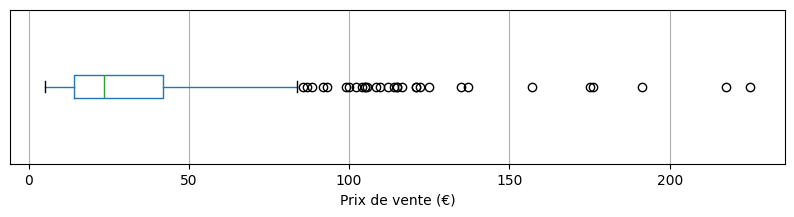

In [75]:
# @deprecated   vert=False                 Use orientation="horizontal" instead
# @bug          orientation="horizontal"   Warning + All xticks set to "price"
df_clean.boxplot("price", vert=False, figsize=(10,2))
plt.xlabel("Prix de vente (€)")
plt.yticks([])
plt.show()

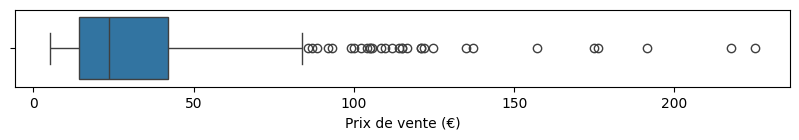

In [76]:
fig, ax = plt.subplots(figsize=(10,1))
sns.boxplot(df_clean, x="price", ax=ax)
plt.xlabel("Prix de vente (€)")
plt.show()

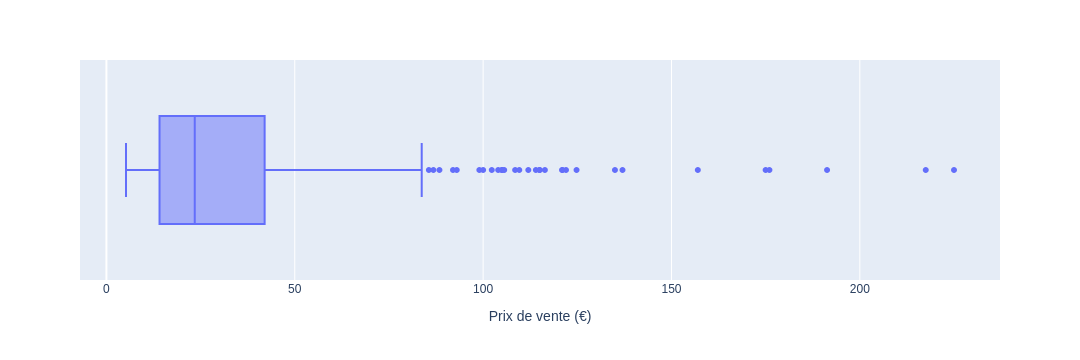

In [77]:
px.box(df_clean, x="price", hover_name="title", labels={"price":"Prix de vente (€)"})

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Exploration par l'utilisation de méthodes statistiques
</h2>
</div>

<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Identification par le Z-index
</h3>
</div>

In [78]:
price_avg = df_clean["price"].mean()
print(f"Prix de vente moyen = {price_avg:_.2f}€")

Prix de vente moyen = 32.37€


In [79]:
price_std = df_clean["price"].std()
print(f"Ecart type du prix de vente = {price_std:_.2f}€")

Ecart type du prix de vente = 27.69€


In [80]:
zscore = (df_clean["price"] - price_avg) / price_std
zscore_scipy = pd.Series(scipy.stats.zscore(df_clean["price"]))
print(f"Ecart max entre les Z-scores de [Pandas only] et [Pandas + SciPy] : {(zscore - zscore_scipy).abs().max():_.2e}")

Ecart max entre les Z-scores de [Pandas only] et [Pandas + SciPy] : 4.95e-03


In [81]:
threshold = 3
above = df_clean["price"][ (zscore >= threshold) ].min()
below = df_clean["price"][ (zscore <= threshold) ].max()
print(f"Z-score({below:_.2f}€) <= {threshold} <= Z-score({above:_.2f}€) [Pandas only]")
above = df_clean["price"][ (zscore_scipy >= threshold) ].min()
below = df_clean["price"][ (zscore_scipy <= threshold) ].max()
print(f"Z-score({below:_.2f}€) <= {threshold} <= Z-score({above:_.2f}€) [Pandas + SciPy]")

Z-score(115.00€) <= 3 <= Z-score(116.40€) [Pandas only]
Z-score(115.00€) <= 3 <= Z-score(116.40€) [Pandas + SciPy]


In [82]:
den = zscore.shape[0]
num = (zscore.abs() > 3).sum()
print(f"Prix de vente outliers : {num}/{den} = {100.*num/den:.2f}% [Pandas only]")
num = (zscore_scipy.abs() > 3).sum()
print(f"Prix de vente outliers : {num}/{den} = {100.*num/den:.2f}% [Pandas + SciPy]")

Prix de vente outliers : 13/704 = 1.85% [Pandas only]
Prix de vente outliers : 13/704 = 1.85% [Pandas + SciPy]


<div style="border: 1px solid #7b002c;">
<h3 style="margin: auto; padding: 20px; color: #7b002c;">
Identification par l'intervalle interquartile
</h3>
</div>

In [83]:
price_describe = df_clean["price"].describe()
price_describe

count    704.000000
mean      32.373438
std       27.690017
min        5.200000
25%       14.100000
50%       23.450000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [84]:
prix_seuil = price_describe["75%"] + 1.5 * (price_describe["75%"] - price_describe["25%"])
print(f"Prix seuil = {prix_seuil:_.2f}€")

Prix seuil = 83.85€


In [85]:
num = (df_clean["price"] > prix_seuil).sum()
den = df_clean.shape[0]
print(f"Prix outliers : {num}/{den} = {100.*num/den:.2f}%")

Prix outliers : 31/704 = 4.40%


In [86]:
df_clean.sort_values(by="price", ascending=False, inplace=True, ignore_index=True)
df_clean[:31]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales
0,4352,225.0,0,137.81,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,11
1,5001,217.5,18,116.87,14581,Vin,David Duband Charmes-Chambertin Grand Cru 2014,david-duband-charmes-chambertin-grand-cru-2014,2
2,5892,191.3,98,116.06,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,6
3,4402,176.0,11,78.25,3510,Cognac,Cognac Frapin VIP XO,cognac-frapin-vip-xo,3
4,5767,175.0,12,90.42,15185,Vin,Camille Giroud Clos de Vougeot 2016,camille-giroud-clos-de-vougeot-2016,4
5,4406,157.0,12,69.08,7819,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,cognac-frapin-chateau-de-fontpinot-1989-20-ans,4
6,4904,137.0,9,67.95,14220,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,domaine-des-croix-corton-charlemagne-grand-cru...,3
7,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5
8,5612,124.8,19,66.41,14915,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,domaine-weinbach-gewurztraminer-gc-furstentum-...,1
9,5917,122.0,12,54.24,14775,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,wemyss-malts-single-cask-scotch-whisky-choc-n-...,3


Les outliers ne semblent *pas aberrants*, ce sont plutôt des produits haut de gamme (e.g. Grand Cru, 1er Cru).

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white;">
Autres analyses univariées
</h1>
</div>

In [87]:
# Pour utiliser la même couleur pour chaque catégorie dans les graphiques
sns.set_theme(style="darkgrid", palette="Set1")         
hue_order = np.sort(pd.unique(df_clean["type"]))    # Seaborn
category_orders = {"type":hue_order}                # Plotly
print(*hue_order, sep=", ")

Champagne, Cognac, Gin, Huile d'olive, Vin, Whisky


<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse des ventes en CA
</h2>
</div>

In [88]:
df_clean["CA"] = df_clean["price"] * df_clean["total_sales"]
df_clean.sort_values(by="CA", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA
0,4352,225.0,0,137.81,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,11,2475.0
1,5892,191.3,98,116.06,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,6,1147.8
2,4353,79.5,127,45.91,12587,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,champagne-egly-ouriet-grand-cru-brut-rose,14,1113.0
3,5826,41.2,34,21.71,15325,Vin,Agnès Levet Côte Rôtie Améthyste 2017,agnes-levet-amethyste-2017,20,824.0
4,6212,115.0,16,59.42,13996,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,domaine-des-comtes-lafon-volnay-1er-cru-santen...,7,805.0
...,...,...,...,...,...,...,...,...,...,...
699,4043,60.0,0,29.45,14980,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,pierre-gaillard-cote-rotie-esprit-blond-2017,0,0.0
700,4396,62.0,0,28.42,9636,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,whisky-wemyss-the-hive-12-ans,0,0.0
701,6301,40.5,0,20.51,15745,Vin,Borie La Vitarèle Saint-Chinian Midi Rouge 2015,borie-la-vitarele-saint-chinian-midi-rouge-2015,0,0.0
702,4051,7.7,0,4.14,16045,Vin,Jeanne Gaillard IGP Collines Rhodaniennes Syra...,pierre-gaillard-syrah-terre-mandrin-2018,0,0.0


In [89]:
ca_total = df_clean["CA"].sum()
print(f"Chiffre d'affaires total = {ca_total:_.2f}€")

Chiffre d'affaires total = 141_867.60€


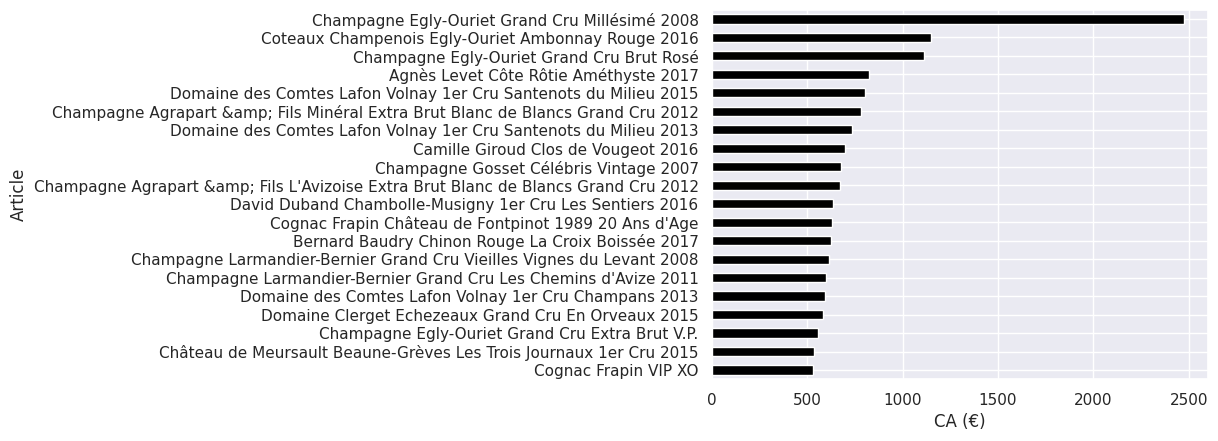

In [90]:
df_clean[19::-1].plot.barh(x="title", y="CA", color="black", legend=False)
plt.ylabel("Article")
plt.xlabel("CA (€)")
plt.show()

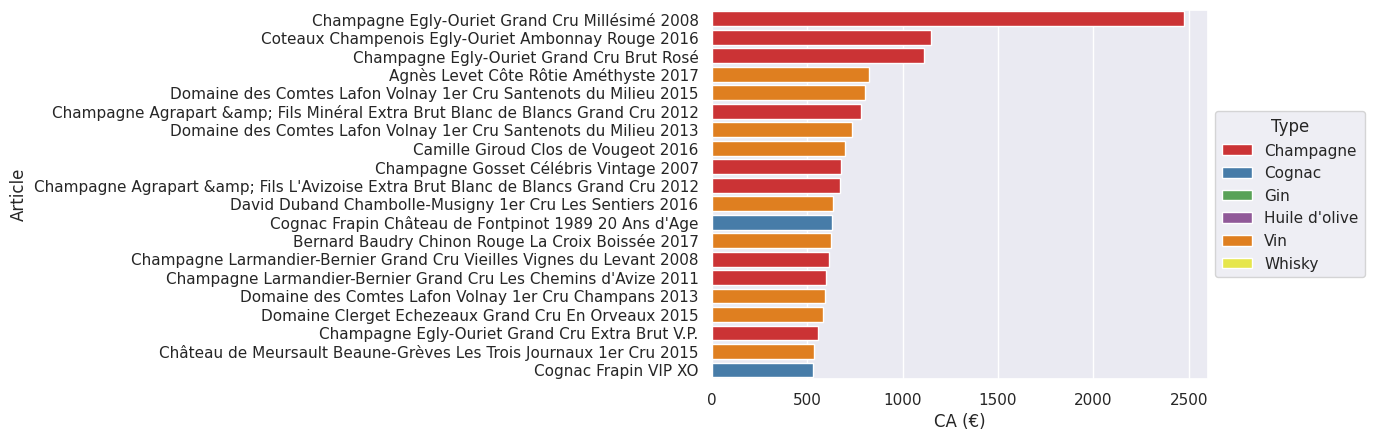

In [91]:
sns.barplot(df_clean[:20], y="title", x="CA", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("CA (€)")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

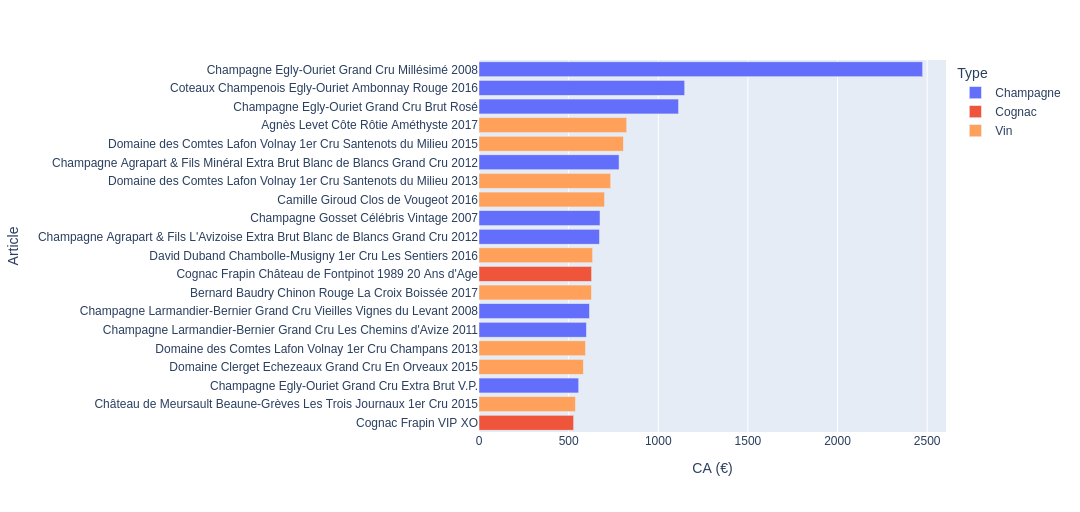

In [92]:
fig = px.bar(
    df_clean[:20], y="title", x="CA", color="type", category_orders=category_orders,
    labels={"title":"Article","CA":"CA (€)","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

Parmi les 20 produits qui rapportent le plus, on trouve principalement des Champagne et des vins, notamment de type Grand Cru ou 1er Cru.

In [93]:
lorenz_data = df_clean.loc[::-1,"CA"] # descending -> ascending
lorenz_data = 100. * lorenz_data / ca_total
lorenz_data = lorenz_data.cumsum()

In [94]:
num = (lorenz_data > 20).sum()
den = df_clean.shape[0]
print(f"Articles représentant 80% du CA : {num}/{den} = {100.*num/den:.2f}%")

Articles représentant 80% du CA : 429/704 = 60.94%


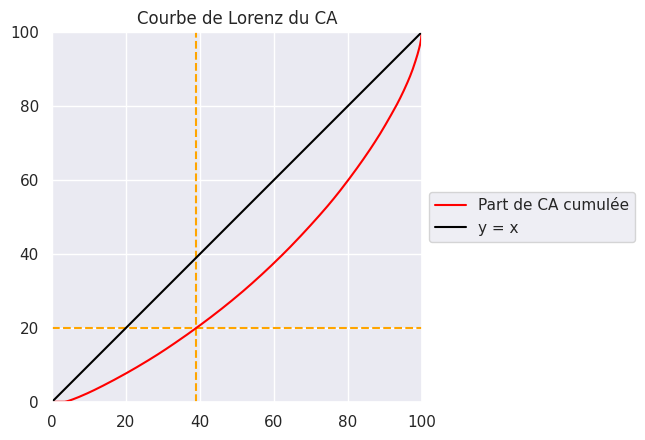

In [95]:
fix, ax = plt.subplots()
ax.set_aspect("equal", adjustable="box")
plt.plot([0,100], [20]*2, color="orange", linestyle="--")
plt.plot([(704-429)/704*100]*2, [0,100], color="orange", linestyle="--")
plt.plot(np.linspace(0,100,704), lorenz_data, color="red", label="Part de CA cumulée")
plt.plot([0,100], [0,100], color="black", label="y = x")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Courbe de Lorenz du CA")
plt.show()

In [96]:
print(f"Indice de Gini = {indice_gini(df_clean["CA"].values):.3f}")

Indice de Gini = 0.323


<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse des ventes en quantité
</h2>
</div>

In [97]:
df_clean.sort_values(by="total_sales", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA
0,4867,9.9,121,4.86,16148,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,36,356.4
1,4203,9.9,74,5.01,15415,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,mas-laval-igp-pays-herault-pampres-blanc-2018,27,267.3
2,4275,14.9,62,7.78,14864,Vin,I Fabbri Chianti Classico Lamole 2017,i-fabbri-chianti-classico-lamole-2017,24,357.6
3,4647,28.5,45,14.14,16525,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,bernard-baudry-chinon-rouge-croix-boissee-2017,22,627.0
4,6129,5.2,68,2.74,14570,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,20,104.0
...,...,...,...,...,...,...,...,...,...,...
699,4052,33.7,0,18.11,16030,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,mont-olivet-chateauneuf-pape-blanc-2019,0,0.0
700,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0
701,5712,57.6,0,30.36,14241,Vin,Albert Mann Gewurztraminer Vendanges Tardives ...,albert-mann-gewurztraminer-vendanges-tardives-...,0,0.0
702,4047,18.3,0,9.93,14977,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,pierre-gaillard-gendrines-2018,0,0.0


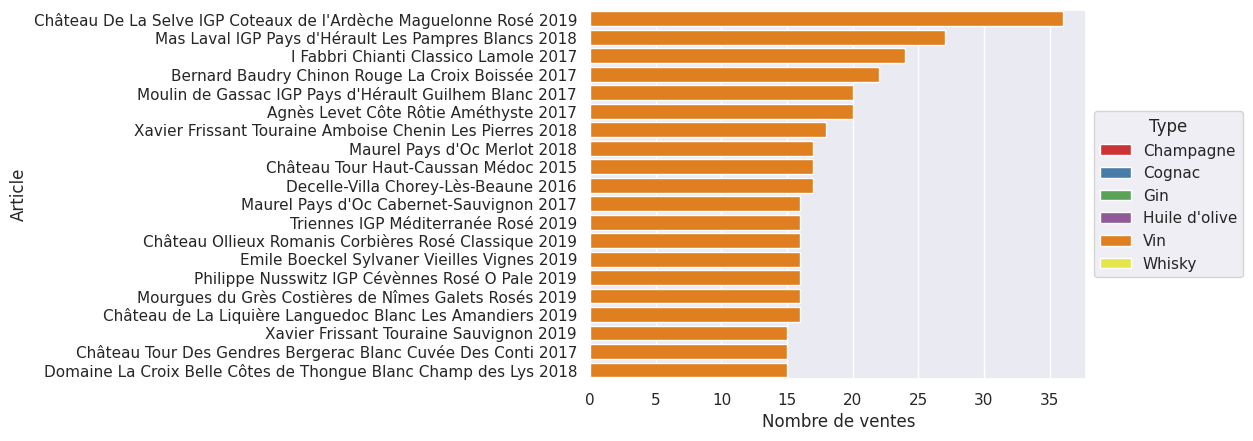

In [98]:
sns.barplot(df_clean[:20], y="title", x="total_sales", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("Nombre de ventes")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

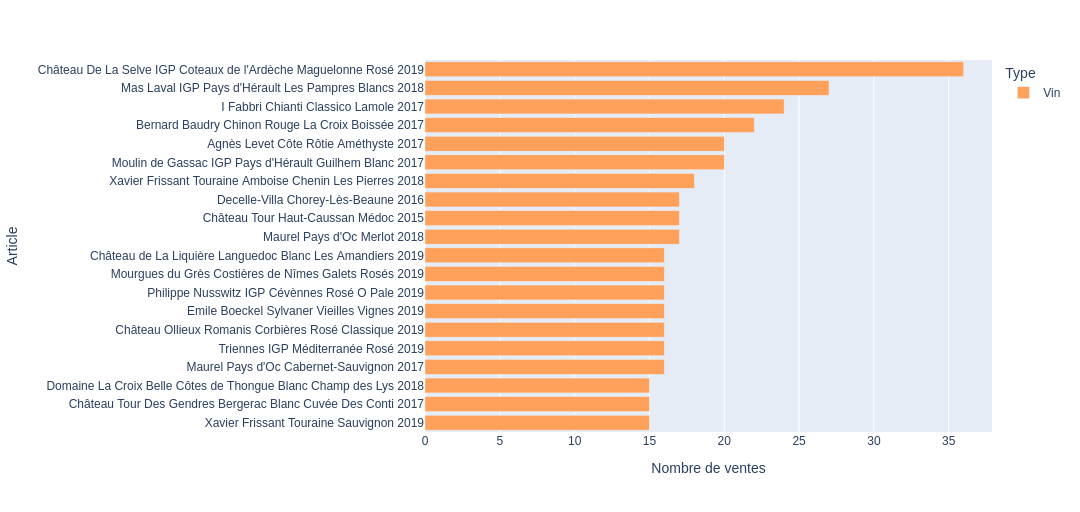

In [99]:
fig = px.bar(
    df_clean[:20], y="title", x="total_sales", color="type", category_orders=category_orders,
    labels={"title":"Article","total_sales":"Nombre de ventes","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

Les 20 produits les plus vendus sont tous des vins.

In [100]:
total_sales_total = df_clean["total_sales"].sum()
print(f"Nombre total de ventes = {total_sales_total}")

Nombre total de ventes = 5668


In [101]:
lorenz_data = df_clean.loc[::-1,"total_sales"] # descending -> ascending
lorenz_data = 100. * lorenz_data / total_sales_total
lorenz_data = lorenz_data.cumsum()

In [102]:
num = (lorenz_data > 20).sum()
den = df_clean.shape[0]
print(f"Articles représentant 80% des ventes en quantité : {num}/{den} = {100.*num/den:.2f}%")

Articles représentant 80% des ventes en quantité : 428/704 = 60.80%


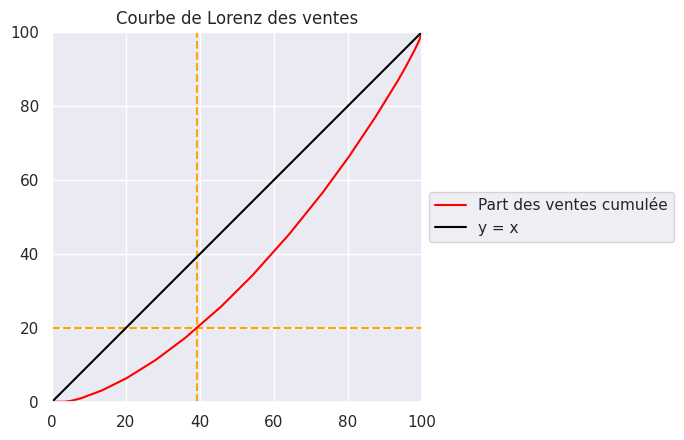

In [103]:
fix, ax = plt.subplots()
ax.set_aspect("equal", adjustable="box")
plt.plot([0,100], [20]*2, color="orange", linestyle="--")
plt.plot([(704-428)/704*100]*2, [0,100], color="orange", linestyle="--")
plt.plot(np.linspace(0,100,704), lorenz_data, color="red", label="Part des ventes cumulée")
plt.plot([0,100], [0,100], color="black", label="y = x")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Courbe de Lorenz des ventes")
plt.show()

In [104]:
print(f"Indice de Gini = {indice_gini(df_clean["total_sales"].values):.3f}")

Indice de Gini = 0.282


<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse des stocks
</h2>
</div>

Les données portent sur le mois d'octobre.
Il est donc possible de calculer le nombre de mois de stock en divisant `stock_quantity` par `total_sales`.

In [105]:
df_clean["nb_months_stock"] = df_clean["stock_quantity"] / df_clean["total_sales"]
df_clean.sort_values(by="nb_months_stock", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
0,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf
1,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf
2,4142,53.0,125,32.15,11641,Champagne,Champagne Gosset Grand Millésime 2006,champagne-gosset-grand-millesime-2006,4,212.0,31.25
3,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5,675.0,27.60
4,4356,51.6,81,31.00,12585,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,champagne-egly-ouriet-premier-cru-vrigny,3,154.8,27.00
...,...,...,...,...,...,...,...,...,...,...,...
699,4052,33.7,0,18.11,16030,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,mont-olivet-chateauneuf-pape-blanc-2019,0,0.0,NaN
700,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0,NaN
701,5712,57.6,0,30.36,14241,Vin,Albert Mann Gewurztraminer Vendanges Tardives ...,albert-mann-gewurztraminer-vendanges-tardives-...,0,0.0,NaN
702,4047,18.3,0,9.93,14977,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,pierre-gaillard-gendrines-2018,0,0.0,NaN


Le nombre de mois de stock est indéfini (NaN) lorsque `stock_quantity` = `total_sales` = 0.

Cela correspond à **22** produits en rupture de stock et sans vente.
Attention : est-ce normal qu'ils apparaissent sur le site web ?

Nous retirons les lignes correspondantes dans la suite de cette analyse (nouveau DataFrame).

In [106]:
print(f"Le nombre de mois de stock est indéfini (NaN) dans {df_clean["nb_months_stock"].isna().sum()} lignes.")

Le nombre de mois de stock est indéfini (NaN) dans 22 lignes.


In [107]:
df_clean[ df_clean["nb_months_stock"].isna() ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
682,4606,50.1,0,24.59,15149,Vin,Catherine et Claude Maréchal Volnay 2017,catherine-et-claude-marechal-volnay-2017,0,0.0,NaN
683,4065,19.5,0,9.67,15022,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...,oratoire-saint-martin-cairanne-douyes-2016,0,0.0,NaN
684,4876,22.8,0,11.90,16289,Vin,Tempier Bandol Rosé 2019,tempier-bandol-rose-2019,0,0.0,NaN
685,4396,62.0,0,28.42,9636,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,whisky-wemyss-the-hive-12-ans,0,0.0,NaN
686,3850,20.8,0,10.64,15300,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...,0,0.0,NaN
687,5544,61.6,0,31.51,14828,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,marc-colin-et-fils-chassagne-montrachet-blanc-...,0,0.0,NaN
688,4043,60.0,0,29.45,14980,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,pierre-gaillard-cote-rotie-esprit-blond-2017,0,0.0,NaN
689,5384,28.8,0,15.18,14149,Vin,Liban Vallée de la Békaa Château Marsyas 2012,liban-vallee-de-la-bekaa-chateau-marsyas-2012,0,0.0,NaN
690,6301,40.5,0,20.51,15745,Vin,Borie La Vitarèle Saint-Chinian Midi Rouge 2015,borie-la-vitarele-saint-chinian-midi-rouge-2015,0,0.0,NaN
691,4923,7.0,0,3.65,15928,Vin,Cave de Castelmaure Corbières Rouge Vigneron 2018,cave-de-castelmaure-corbieres-rouge-vigneron-2018,0,0.0,NaN


In [108]:
df_stock_rotation = df_clean[ df_clean["nb_months_stock"].notna() ]
df_stock_rotation.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 682 entries, 0 to 681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       682 non-null    int64  
 1   price            682 non-null    float64
 2   stock_quantity   682 non-null    int64  
 3   purchase_price   682 non-null    float64
 4   sku              682 non-null    object 
 5   type             682 non-null    object 
 6   title            682 non-null    object 
 7   name             682 non-null    object 
 8   total_sales      682 non-null    int64  
 9   CA               682 non-null    float64
 10  nb_months_stock  682 non-null    float64
dtypes: float64(4), int64(3), object(4)
memory usage: 63.9+ KB


Le nombre de mois de stock est infini lorsque `stock_quantity` > 0 et `total_sales` = 0.

Cela correspond à **2** produits en stock et sans vente. Attention : pourquoi personne n'achète ces produits ?

Nous retirons les lignes correspondantes dans la suite de cette analyse.

In [109]:
print(f"Le nombre de mois de stock est infini dans {(~np.isfinite(df_stock_rotation["nb_months_stock"])).sum()} lignes.")

Le nombre de mois de stock est infini dans 2 lignes.


In [110]:
df_stock_rotation[ ~np.isfinite(df_stock_rotation["nb_months_stock"]) ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
0,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf
1,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf


In [111]:
df_stock_rotation = df_stock_rotation[ np.isfinite(df_stock_rotation["nb_months_stock"]) ]
df_stock_rotation.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 680 entries, 2 to 681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       680 non-null    int64  
 1   price            680 non-null    float64
 2   stock_quantity   680 non-null    int64  
 3   purchase_price   680 non-null    float64
 4   sku              680 non-null    object 
 5   type             680 non-null    object 
 6   title            680 non-null    object 
 7   name             680 non-null    object 
 8   total_sales      680 non-null    int64  
 9   CA               680 non-null    float64
 10  nb_months_stock  680 non-null    float64
dtypes: float64(4), int64(3), object(4)
memory usage: 63.8+ KB


Le nombre de mois de stock est nul lorsque `stock_quantity` = 0 et `total_sales` > 0.

Cela correspond à **20** produits vendus en rupture de stock. Attention : faut-il prévoir un réapprovisionnement ?

In [112]:
print(f"Le nombre de mois de stock est nul dans {(df_stock_rotation["nb_months_stock"] == 0).sum()} lignes.")

Le nombre de mois de stock est nul dans 20 lignes.


In [113]:
df_stock_rotation[ (df_stock_rotation["nb_months_stock"] == 0) ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
662,4274,12.90,0,6.33,12942,Vin,Domaine Sérol Vin Mousseux Rosé Turbullent Mét...,domaine-serol-mousseux-turbullent,8,103.20,0.0
663,4870,9.30,0,4.81,16149,Vin,Triennes IGP Méditerranée Rosé 2019,triennes-igp-mediterranee-rose-2019,16,148.80,0.0
664,4283,27.00,0,13.25,16154,Vin,Château de Cazeneuve Pic Saint-Loup Le Roc Des...,chateau-de-cazeneuve-pic-saint-loup-roc-des-ma...,8,216.00,0.0
665,6050,38.50,0,20.09,15134,Vin,Christophe Pichon Condrieu 2017,christophe-pichon-saint-condrieu-2017,6,231.00,0.0
666,5617,27.80,0,14.65,14844,Vin,Albert Boxler Pinot Gris Réserve 2016,albert-boxler-pinot-gris-reserve-2016,9,250.20,0.0
667,5487,43.50,0,23.37,16129,Vin,Decelle-Villa Nuits-Saint-Georges Rouge 2016,decelle-villa-nuits-st-georges-rouge-2016,9,391.50,0.0
668,5709,31.70,0,16.54,15035,Vin,Philippe Alliet Chinon Rouge Coteau de Noiré 2016,alliet-chinon-rouge-noire-2016,5,158.50,0.0
669,4256,24.40,0,12.61,14253,Vin,Domaine Huet Vouvray Haut-Lieu Sec 2017,domaine-huet-vouvray-haut-lieu-sec-2016,9,219.60,0.0
670,4179,24.00,0,13.02,16166,Vin,Domaine de l'Hortus Pic Saint-Loup La Grande C...,hortus-pic-saint-loup-grande-cuvee-2018,6,144.00,0.0
671,4976,16.45,0,8.07,16005,Vin,Château Lafont Menaut Pessac-Leognan Rouge 2017,chateau-lafont-menaut-pessac-leognan-rouge-2017,7,115.15,0.0


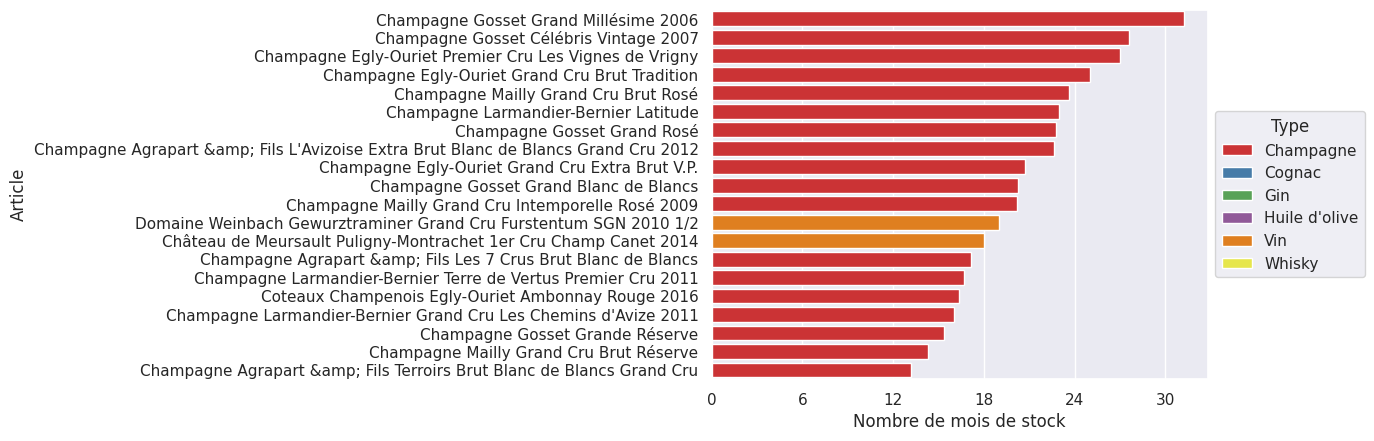

In [114]:
sns.barplot(df_stock_rotation[:20], y="title", x="nb_months_stock", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("Nombre de mois de stock")
plt.xticks(range(0,36,6))
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

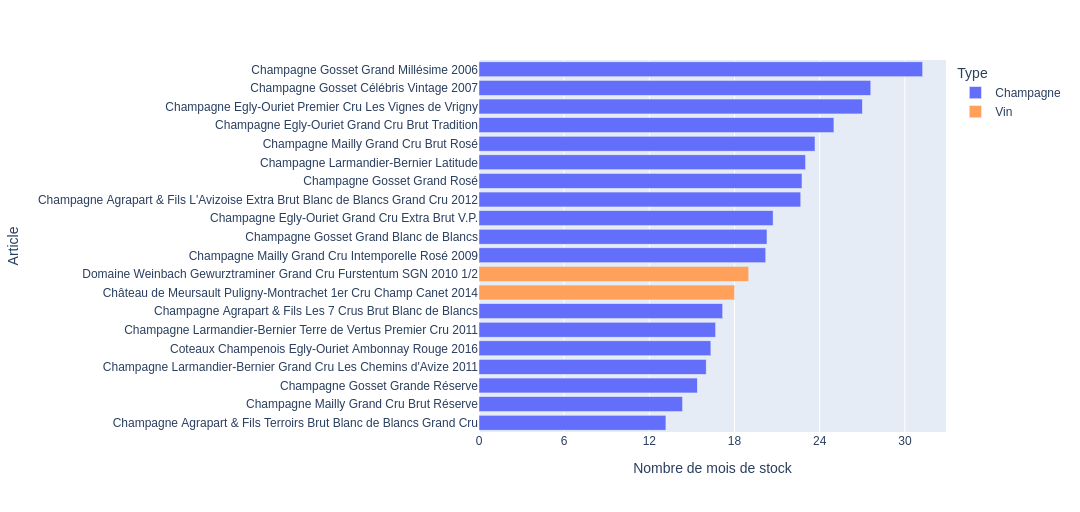

In [115]:
fig = px.bar(
    df_stock_rotation[:20], y="title", x="nb_months_stock", color="type", category_orders=category_orders,
    labels={"title":"Article","nb_months_stock":"Nombre de mois de stock","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending", xaxis={"dtick":6})
fig.show()

Le nombre de mois de stock semble très élevé (jusqu'à plus de 2 ans) avec des produits haut de gamme (e.g. Champagne, Grand Cru).

In [116]:
df_clean["stock_valorisation_euros"] = df_clean["purchase_price"] * df_clean["stock_quantity"]

In [117]:
stock_valorisation_euros_total = df_clean["stock_valorisation_euros"].sum()
print(f"Valorisation en € de l'ensemble du stock = {stock_valorisation_euros_total:_.2f}€")

Valorisation en € de l'ensemble du stock = 264_691.70€


In [118]:
stock_valorisation_count_total = df_clean["stock_quantity"].sum()
print(f"Nombre d'unités en stock = {stock_valorisation_count_total:_d}")

Nombre d'unités en stock = 16_425


*Rappel : les données portent sur le mois d'octobre.* Une anticipation de hausse des ventes pour les fêtes de fin d'année peut expliquer ce sur-stockage.

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse de la marge
</h2>
</div>

In [119]:
df_clean["marge"] = 100. * (df_clean["price"] - df_clean["purchase_price"]) / df_clean["purchase_price"]
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock,stock_valorisation_euros,marge
0,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf,353.34,120.382634
1,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf,7090.50,69.734151
2,4142,53.0,125,32.15,11641,Champagne,Champagne Gosset Grand Millésime 2006,champagne-gosset-grand-millesime-2006,4,212.0,31.25,4018.75,64.852255
3,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5,675.0,27.60,11085.54,68.056766
4,4356,51.6,81,31.00,12585,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,champagne-egly-ouriet-premier-cru-vrigny,3,154.8,27.00,2511.00,66.451613
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,4052,33.7,0,18.11,16030,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,mont-olivet-chateauneuf-pape-blanc-2019,0,0.0,NaN,0.00,86.085036
700,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0,NaN,0.00,91.623864
701,5712,57.6,0,30.36,14241,Vin,Albert Mann Gewurztraminer Vendanges Tardives ...,albert-mann-gewurztraminer-vendanges-tardives-...,0,0.0,NaN,0.00,89.723320
702,4047,18.3,0,9.93,14977,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,pierre-gaillard-gendrines-2018,0,0.0,NaN,0.00,84.290030


In [120]:
df_clean["marge"].describe()

count    704.000000
mean      93.524039
std        9.456904
min       55.397390
25%       87.895212
50%       93.528757
75%       99.556541
max      129.694965
Name: marge, dtype: float64

In [121]:
df_marge_avg = df_clean[["type","marge"]].groupby("type").mean().sort_values(by="marge", ascending=False).reset_index()
df_marge_avg

,type,marge
0,Cognac,118.779435
1,Whisky,118.087005
2,Gin,109.790210
3,Vin,93.808889
4,Champagne,68.003774
5,Huile d'olive,60.068162


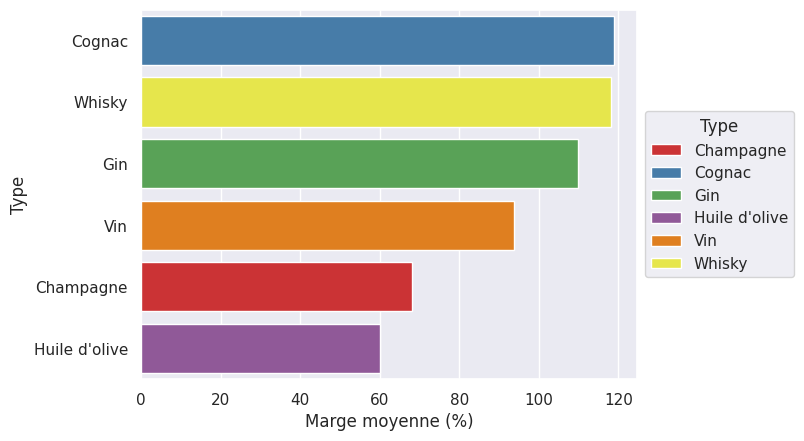

In [122]:
sns.barplot(df_marge_avg, y="type", x="marge", hue="type", hue_order=hue_order, legend=True)
plt.ylabel("Type")
plt.xlabel("Marge moyenne (%)")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

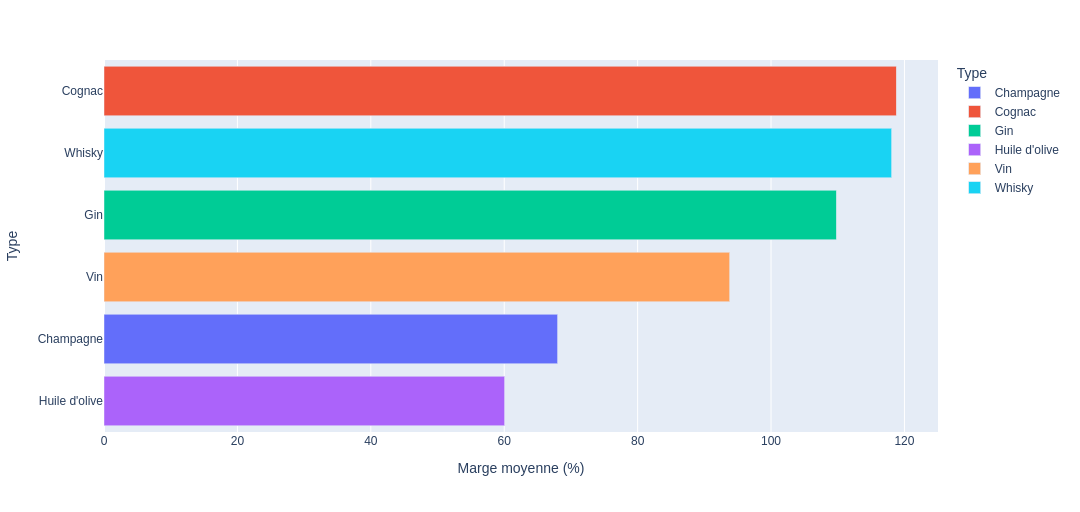

In [123]:
fig = px.bar(
    df_marge_avg, y="type", x="marge", color="type", category_orders=category_orders,
    labels={"type":"Type","marge":"Marge moyenne (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

La marge moyenne est élevée pour toutes les catégories (minimum 60% pour l'huile d'olive, maximum 120% pour le Cognac et le Whisky).

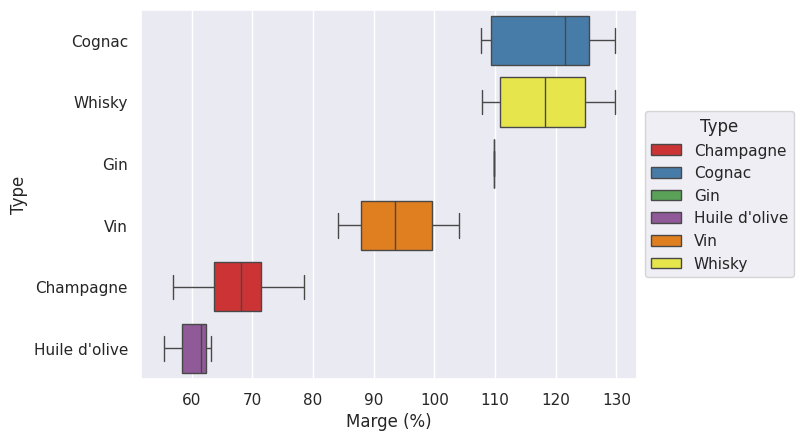

In [124]:
sns.boxplot(df_clean, y="type", x="marge", hue="type", hue_order=hue_order, order=df_marge_avg["type"])
plt.ylabel("Type")
plt.xlabel("Marge (%)")
plt.legend(hue_order, title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

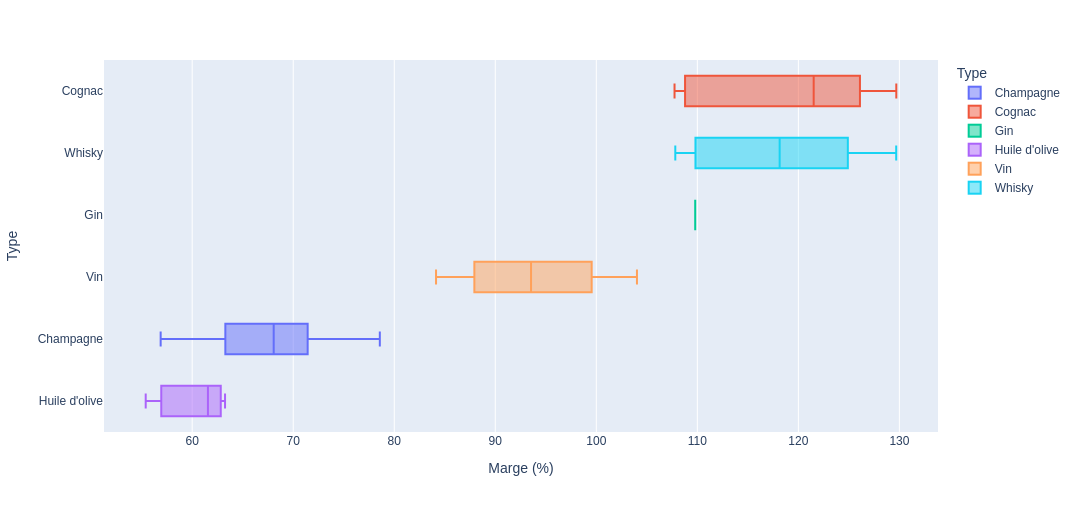

In [125]:
fig = px.box(
    df_clean, y="type", x="marge", color="type", category_orders=category_orders,
    labels={"type":"Type","marge":"Marge (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

L'ordre selon la marge médiane est le même que l'ordre selon la marge moyenne.

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white; ">
Analyse des corrélations
</h1>
</div>

In [126]:
df_corr = df_clean[["purchase_price","price","marge","total_sales","CA","stock_quantity","nb_months_stock"]].corr()
df_corr

,purchase_price,price,marge,total_sales,CA,stock_quantity,nb_months_stock
purchase_price,1.000000,0.992116,-0.127003,-0.497714,0.664794,-0.051347,0.260847
price,0.992116,1.000000,-0.031216,-0.518164,0.628353,-0.110841,0.209303
marge,-0.127003,-0.031216,1.000000,-0.034960,-0.190371,-0.444567,-0.461292
total_sales,-0.497714,-0.518164,-0.034960,1.000000,0.108711,0.471127,-0.065093
CA,0.664794,0.628353,-0.190371,0.108711,1.000000,0.173324,0.141457
stock_quantity,-0.051347,-0.110841,-0.444567,0.471127,0.173324,1.000000,0.776553
nb_months_stock,0.260847,0.209303,-0.461292,-0.065093,0.141457,0.776553,1.000000


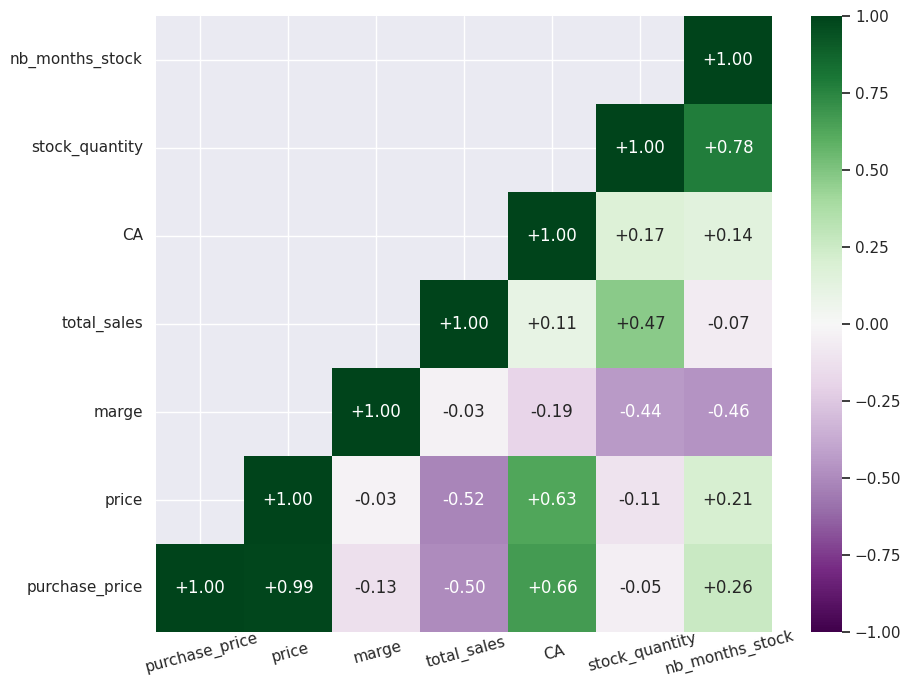

In [127]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_corr[::-1], annot=True, fmt="+.2f", vmin=-1, vmax=1, cmap="PRGn", square=True, mask=np.tri(*df_corr.shape,-1)[::-1], ax=ax)
plt.xticks(rotation=15, rotation_mode="anchor")
plt.show()

Analyse des corrélations positives
- +0.99 entre `price` et `purchase_price` (analyse approfondie ci-dessous, cf. 6.1)  
  Cette corrélation est très forte. Les corrélations de chacune de ces deux variables avec une autre variable sont très proches.  
  C'est pourquoi nous ne regardons désormais plus que `price`.
- +0.78 entre `nb_months_stock` et `stock_quantity`  
  Cela est dû à la relation : `nb_months_stock` = `stock_quantity` / `total_sales`  
  Cette corrélation est forte. Les corrélations de chacune de ces deux variables avec une autre variable (sauf `total_sales`) sont assez proches.  
  C'est pourquoi nous ne regardons désormais plus que `stock_quantity`.
- +0.63 entre `CA` et `price`  
  Cela est dû à la relation : `CA` = `price` × `total_sales`
- +0.47 entre `stock_quantity` et `total_sales`  
  Les niveaux de stock fin octobre correspondent à peu près aux volumes des ventes réalisées sur ce mois.

Analyse des corrélations négatives
- -0.52 entre `total_sales` et `price`  
  Un prix élevé a tendance à tirer les ventes à la baisse.
- -0.44 entre `marge` et `stock_quantity`  
  Le stock contient en majorité des produits dont la marge est plus petite.  
  Cela est cohérent avec le sur-stockage des Champagne (cf. 5.3) dont la marge est inférieure à celle des autres catégories (cf. 5.4).

<div style="border: 1px solid #7b002c;">
<h2 style="margin: auto; padding: 20px; color: #7b002c;">
Analyse bivariée entre le prix de vente et le prix fournisseur
</h2>
</div>

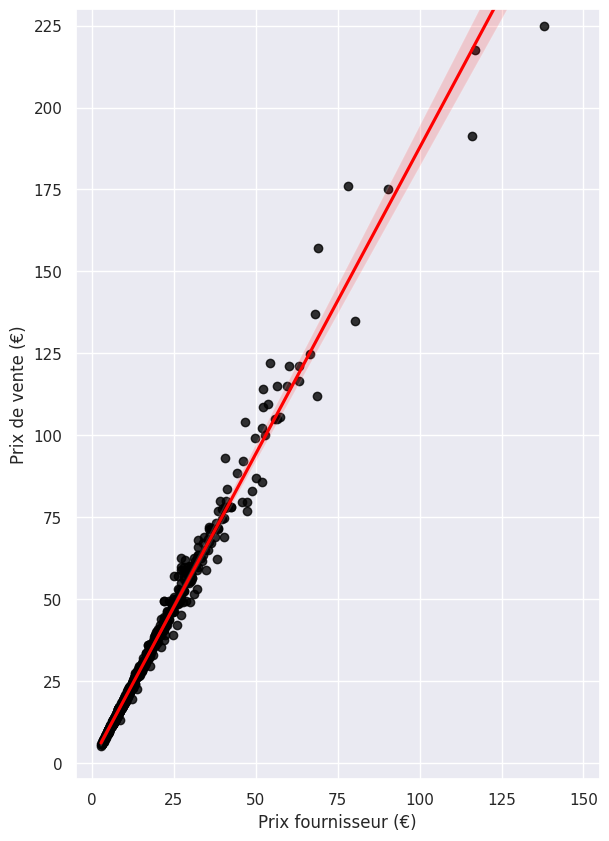

In [128]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect("equal", adjustable="box")
sns.regplot(df_clean, y="price", x="purchase_price", color="black", line_kws={"color":"red"}, ax=ax)
plt.ylabel("Prix de vente (€)")
plt.xlabel("Prix fournisseur (€)")
plt.xticks(range(0,151,25))
plt.yticks(range(0,226,25))
plt.xlim(-5, 155)
plt.ylim(-5, 230)
plt.show()

In [129]:
result = scipy.stats.linregress(df_clean["purchase_price"], df_clean["price"])
a = result.slope
b = result.intercept
r = result.rvalue
print(f"Equation de droite : y={a:.3f}x{b:+.3f}")
print(f"Coefficient de corrélation (Pearson) : R = {r:+.3f}")
print(f"Coefficient de détermination : R² = {r*r:.3f}")

Equation de droite : y=1.868x+0.948
Coefficient de corrélation (Pearson) : R = +0.992
Coefficient de détermination : R² = 0.984


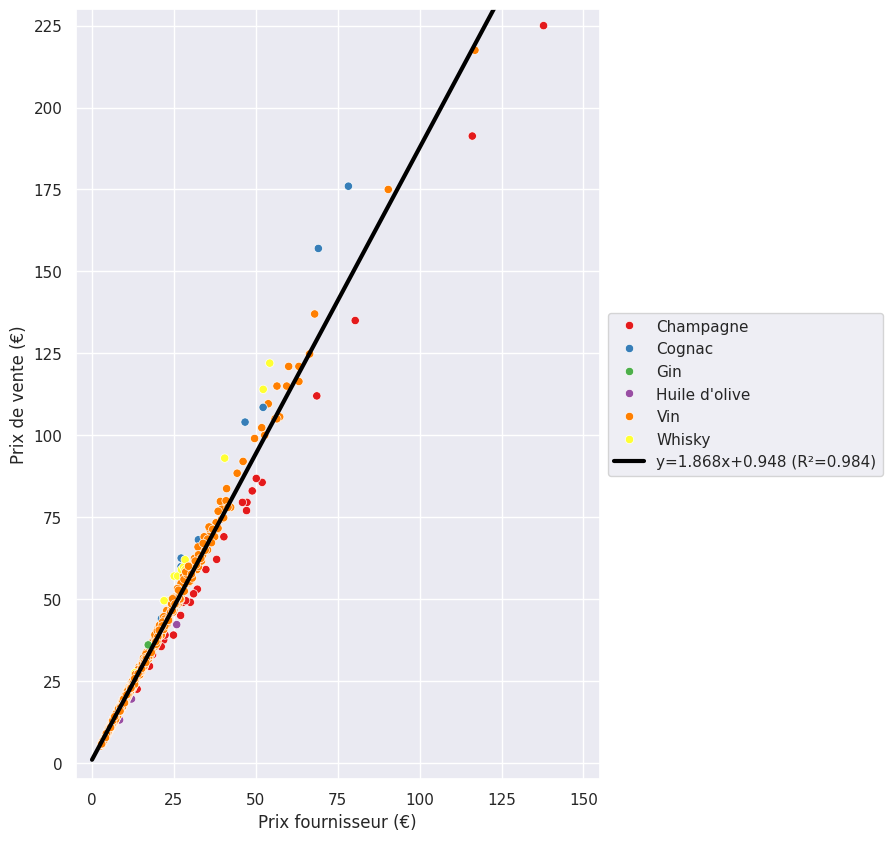

In [130]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect("equal", adjustable="box")
sns.scatterplot(df_clean, y="price", x="purchase_price", hue="type", hue_order=hue_order, ax=ax)
plt.plot([0,150], [a*0+b,a*150+b], color="black", linewidth=3, label=f"y={a:.3f}x{b:+.3f} (R²={r*r:.3f})")
plt.ylabel("Prix de vente (€)")
plt.xlabel("Prix fournisseur (€)")
plt.xticks(range(0,151,25))
plt.yticks(range(0,226,25))
plt.xlim(-5, 155)
plt.ylim(-5, 230)
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

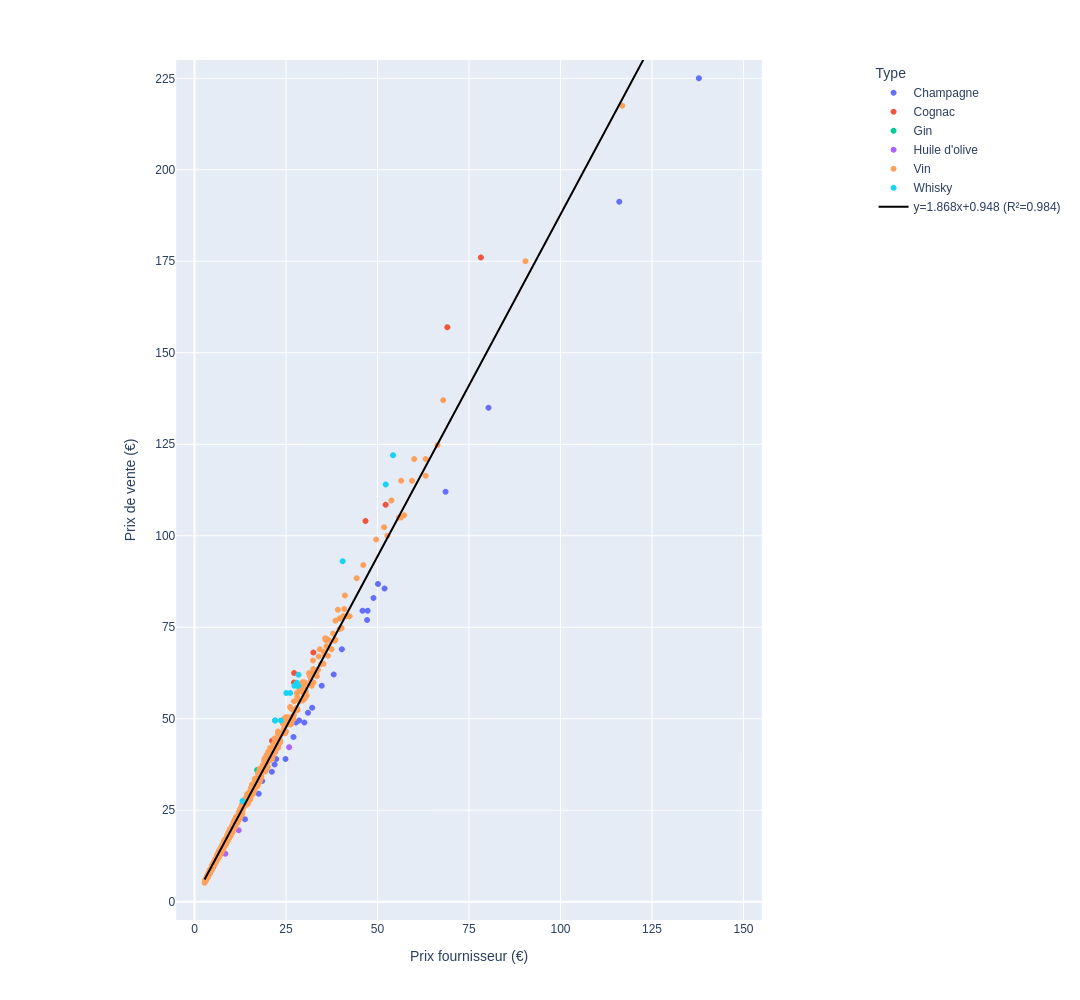

In [131]:
fig = px.scatter(
    df_clean, y="price", x="purchase_price", hover_name="title", color="type", category_orders=category_orders,
    labels={"type":"Type","purchase_price":"Prix fournisseur (€)","price":"Prix de vente (€)"},
    trendline="ols", trendline_scope="overall", trendline_color_override="black",
)
fig.for_each_trace(lambda trace: trace.update(name=trace.name.replace("Overall Trendline", f"y={a:.3f}x{b:+.3f} (R²={r*r:.3f})")))
fig.update_layout(
    width=900, height=1000,
    xaxis={"range":(-5,155),"dtick":25,"constrain":"domain"},
    yaxis={"range":(-5,230),"dtick":25,"constrain":"domain","scaleanchor":"x","scaleratio":1},
)
fig.show()

In [132]:
px.get_trendline_results(fig).iloc[0,0].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                 4.399e+04
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:43:23   Log-Likelihood:                -1874.4
No. Observations:                 704   AIC:                             3753.
Df Residuals:                     702   BIC:                             3762.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9478      0.199      4.764      0.000       0.557       1.338
x1             1.8684      0.009    209.743      0.000       1.851       1.886
==============================================================================
Omnibus:                      227.744   Durbin-Watson:                   1.879
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            31674.011
Skew:                          -0.068   Prob(JB):                         0.00
Kurtosis:                      35.860   Cond. No.                         34.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<div style="background-color: #7b002c;">
<h1 style="margin: auto; padding: 20px; color: white; ">
Export au format Excel
</h1>
</div>

Export des données sélectionnées pour les analyses (**704** lignes, cf. 3.4)

In [133]:
df_clean.sort_values(by="product_id", inplace=True, ignore_index=True)
df_clean.to_excel("data/données-analyses.xlsx")

Export des données exclues des analyses (**123** lignes)

- 825 - 704 = **121** lignes qui violent *une ou plusieurs* conditions de sélection (cf. 3.4)
- **2** lignes pour les produits sans SKU dans `df_web_product`

In [134]:
df_other = df_merge[ ~df_merge["product_id"].isin(df_clean["product_id"]) ].sort_values(by="product_id", ignore_index=True)
df_other.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   product_id            121 non-null    int64   
 1   onsale_web            121 non-null    int64   
 2   price                 121 non-null    float64 
 3   stock_quantity        121 non-null    int64   
 4   stock_status          121 non-null    object  
 5   purchase_price        121 non-null    float64 
 6   id_web                30 non-null     object  
 7   sku                   10 non-null     object  
 8   type                  10 non-null     object  
 9   title                 10 non-null     object  
 10  name                  10 non-null     object  
 11  total_sales__product  10 non-null     float64 
 12  total_sales__image    10 non-null     float64 
 13  indicator             121 non-null    category
dtypes: category(1), float64(4), int64(3), object(6)
memory usa

In [135]:
df_web_sku_nan = df_web_product[ df_web_product["sku"].isna() ]
df_web_sku_nan = df_web_sku_nan[["sku","product_type","post_title","post_name","total_sales"]]
df_web_sku_nan.rename(
    columns={"product_type":"type","post_title":"title","post_name":"name","total_sales":"total_sales__product"},
    inplace=True,
)
df_web_sku_nan["indicator"] = "web_product"
df_web_sku_nan

,sku,type,title,name,total_sales__product,indicator
1084,NaN,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018,-56.0,web_product
1087,NaN,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017,-17.0,web_product


In [136]:
df_other = pd.concat([ df_other, df_web_sku_nan ], ignore_index=True)
df_other.loc[(df_other["indicator"] == "left_only"),"indicator"] = "erp"
df_other.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            121 non-null    float64
 1   onsale_web            121 non-null    float64
 2   price                 121 non-null    float64
 3   stock_quantity        121 non-null    float64
 4   stock_status          121 non-null    object 
 5   purchase_price        121 non-null    float64
 6   id_web                30 non-null     object 
 7   sku                   10 non-null     object 
 8   type                  12 non-null     object 
 9   title                 12 non-null     object 
 10  name                  12 non-null     object 
 11  total_sales__product  12 non-null     float64
 12  total_sales__image    10 non-null     float64
 13  indicator             123 non-null    object 
dtypes: float64(7), object(7)
memory usage: 13.6+ KB


In [137]:
df_other.tail()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
118,7203.0,0.0,45.0,30.0,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,erp
119,7204.0,0.0,45.0,9.0,instock,24.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,erp
120,7329.0,0.0,26.5,14.0,instock,13.42,14680-1,NaN,NaN,NaN,NaN,NaN,NaN,erp
121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018,-56.0,NaN,web_product
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017,-17.0,NaN,web_product


In [138]:
df_other.to_excel("data/données-à-vérifier.xlsx")